<a href="https://colab.research.google.com/github/diseasemodeling/MIE_525_625/blob/main/Lectures/3b_Code_MLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP for classification problems

# Below is a code for a classification problem, with 3 classes

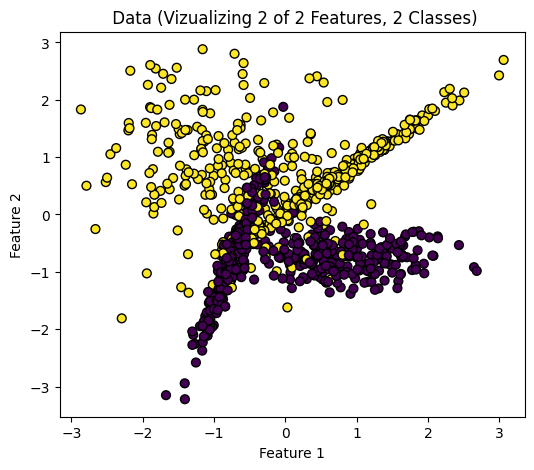

In [33]:
#Generated using ChatGPT
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# ----- Generate toy data -----
#X, y = make_classification(n_samples=1000, n_features=20, n_classes=3,
#                           n_informative=10, n_redundant=0, random_state=42)

# 2D dataset (easier to visualize)
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2,
                           n_informative=2, n_redundant=0, random_state=42)

X = StandardScaler().fit_transform(X) #Standardization (z-score scaling: mean=0, std=1)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", edgecolor="k", s=40)
plt.title(f" Data (Vizualizing 2 of {X.shape[1]} Features, {len(set(y))} Classes)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Epoch 000 | Train MSE: 0.7376 | Val MSE: 0.6371
Epoch 001 | Train MSE: 0.6418 | Val MSE: 0.5546
Epoch 020 | Train MSE: 0.3332 | Val MSE: 0.2626
Epoch 040 | Train MSE: 0.3015 | Val MSE: 0.2540
Epoch 060 | Train MSE: 0.2817 | Val MSE: 0.2322
Epoch 080 | Train MSE: 0.2609 | Val MSE: 0.2174
Epoch 100 | Train MSE: 0.2398 | Val MSE: 0.2005
Epoch 120 | Train MSE: 0.2231 | Val MSE: 0.1840
Epoch 140 | Train MSE: 0.2124 | Val MSE: 0.1722


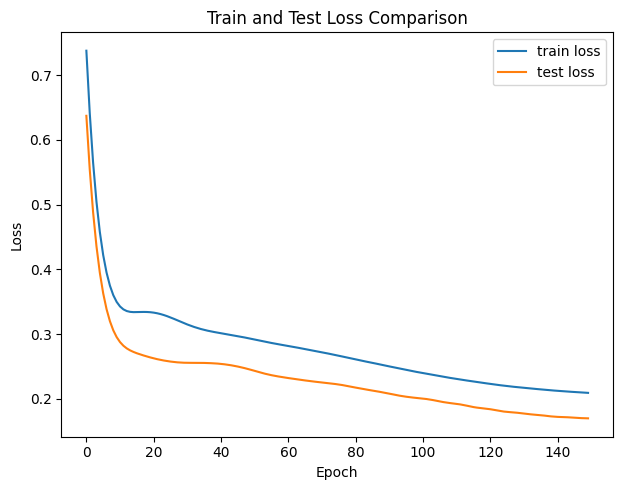

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)   # keep float for WrongMLP
y_test  = torch.tensor(y_test, dtype=torch.float32)

input_dim = X.shape[1]
output_dim = len(set(y))  # number of classes

class MLPClassifier(nn.Module):
    def __init__(self):
        super(MLPClassifier, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim) #Output has nodes equal to number of classes  = in ML language they are called logits (they are raw outputs which do not sum to 1 or have value 0 to 1).(In math logits are log odds of a probability=log(p/(1-p)))
                                      #OUr interest is a probability distribution, which can be obtained by passing outputs through a softmax function (The connection to logits comes from this)
        )
    def forward(self, x): #Softmax is typically added in the output layer to generate a probability.
                          #For classification  problems , instead of MSE loss, we use Cross-Entropy Loss which measures the dissimilarity between two distributions; H(p,q)=- \sum p log (q);;
                          #IN pytorch Cross Entropy loss is set as H(p,q)=- \sum p log (softmax(q)); i.e., softmax is coded into the loss function
        return self.fc(x)

# ----- Training function -----
def train_model(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs=50, correct=True):
    losses, test_losses = [], []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train.long())#inputs to Entropy loss need to be int64
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            test_logits = model(X_test)
            test_loss = criterion(test_logits, y_test.long()).item()
            #pred_probabilities = torch.softmax(test_logits, dim=1)

        losses.append(loss.item())
        test_losses.append(test_loss)
        if epoch % 20 == 0 or epoch == 1:
          print(f"Epoch {epoch:03d} | Train MSE: {loss.item():.4f} | Val MSE: {test_loss:.4f}")
    return losses, test_losses


# ----- Train both models -----
model = MLPClassifier()
losses, test_losses = train_model(
    model,
    nn.CrossEntropyLoss(),
    optim.Adam(model.parameters(), lr=0.01),
    X_train, y_train, X_test, y_test,
    epochs=150, correct=True
)

# ----- Plot  -----
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(losses, label="train loss")
plt.plot(test_losses, label="test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Test Loss Comparison")
plt.legend()

plt.tight_layout()
plt.show()


In [35]:
with torch.no_grad():
        test_logits = model(X_test)
        pred_probabilities = torch.softmax(test_logits, dim=1)# Apply softmax along the class dimension (dim=1) to get probabilities
#print(pred_probabilities)

# Ungraded Assignment :
- Do hyperparamter tuning to improve model fit
- Do regularization to avoid overfit
- Generate F1 score, AUC for precision-recall curve, AUC for ROC curve